# Projet 3 — Backtesting d'une stratégie systématique
## Notebook 08b — Screening S&P 500 et sélection de la meilleure paire

**Rôle.** On applique le pipeline de screening (identique au 06b) à l'univers S&P 500 élargi (~207 titres, 21 secteurs, 1099 paires intra-secteur). Objectif : trouver, de façon systématique et rigoureuse, une paire cointégrée qui trade mieux que nos essais précédents (KO/PEP rejetée, BAC/PNC modeste).

Pipeline : filtre secteur → corrélation → Engle-Granger → **Benjamini-Hochberg** → robustesse temporelle → score → **backtest des meilleures** → sélection finale.

> Le calcul de cointégration sur ~950 paires prend quelques minutes.


In [1]:
import numpy as np, pandas as pd
from itertools import combinations
import statsmodels.api as sm
from statsmodels.tsa.stattools import coint
from statsmodels.stats.multitest import multipletests
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"]=(11,4.5); plt.rcParams["axes.grid"]=True; plt.rcParams["grid.alpha"]=0.3

adj = pd.read_csv("../data/sp500_adj_close.csv", index_col=0, parse_dates=True)
sectors = pd.read_csv("../data/sp500_sectors.csv", index_col="ticker")["secteur"]
log_ret = np.log(adj).diff().dropna()
print("Univers :", adj.shape[1], "titres |", adj.shape[0], "jours |",
      adj.index.min().date(), "->", adj.index.max().date())

Univers : 207 titres | 3709 jours | 2011-11-17 -> 2026-08-21


## 1. Filtre secteur + filtre corrélation
On ne teste que les paires intra-secteur dont la corrélation des rendements dépasse 0,4.


In [2]:
CORR_MIN = 0.40
candidates = []
for sec in sectors.unique():
    names = sectors[sectors == sec].index.tolist()
    for a, b in combinations(sorted(names), 2):
        c = log_ret[a].corr(log_ret[b])
        if c >= CORR_MIN:
            candidates.append({"paire": f"{a}/{b}", "a": a, "b": b, "secteur": sec, "corr": c})
cand = pd.DataFrame(candidates)
print(f"Paires intra-secteur retenues après filtre corrélation : {len(cand)}")

Paires intra-secteur retenues après filtre corrélation : 951


## 2. Engle-Granger + correction Benjamini-Hochberg

Le point crucial sur un grand univers : sans correction, beaucoup de paires « passent » par hasard. La correction FDR est ici indispensable.


In [3]:
def eg_pvalue(y, x):
    return min(coint(y, x)[1], coint(x, y)[1])

cand["p_value"] = [eg_pvalue(adj[r.a], adj[r.b]) for r in cand.itertuples()]
reject, p_bh, _, _ = multipletests(cand["p_value"], alpha=0.05, method="fdr_bh")
cand["p_bh"] = p_bh; cand["signif_bh"] = reject

n_naif = int((cand["p_value"] < 0.05).sum())
n_bh = int(cand["signif_bh"].sum())
print(f"Significatives SANS correction : {n_naif}")
print(f"Significatives APRÈS Benjamini-Hochberg : {n_bh}")
print(f"=> {n_naif - n_bh} paires écartées comme probables faux positifs "
      f"({100*(n_naif-n_bh)/max(n_naif,1):.0f}% des 'découvertes' naïves)")

Significatives SANS correction : 105
Significatives APRÈS Benjamini-Hochberg : 6
=> 99 paires écartées comme probables faux positifs (94% des 'découvertes' naïves)


**La leçon du multiple testing, en chiffres.** Sur un univers de cette taille, la grande majorité des paires « significatives » à 5 % sont en réalité des faux positifs. La correction Benjamini-Hochberg est ce qui sépare les vraies paires cointégrées du bruit statistique. C'est un argument fort à mettre en avant dans le rapport.


## 3. Robustesse temporelle et score


In [4]:
def hedge_spread(y, x):
    beta = sm.OLS(y, sm.add_constant(x)).fit().params.iloc[1]; return beta, y - beta * x
def half_life(spread):
    lag = spread.shift(1).dropna(); dl = (spread - spread.shift(1)).dropna(); lag = lag.loc[dl.index]
    b = sm.OLS(dl, sm.add_constant(lag)).fit().params.iloc[1]
    return np.log(2)/(-b) if b < 0 else np.nan
def subwindow_frac(y, x):
    yrs = sorted(set(y.index.year)); h = t = 0
    for yr in range(yrs[0], yrs[-1], 2):
        m = (y.index.year >= yr) & (y.index.year < yr + 2)
        if m.sum() < 200: continue
        t += 1
        if coint(y[m], x[m])[1] < 0.05: h += 1
    return h/t if t else np.nan
def beta_cv(y, x, win=252):
    b = (y.rolling(win).cov(x)/x.rolling(win).var()).dropna()
    return b.std()/abs(b.mean()) if b.mean() != 0 else np.nan
def hl_score(hl):
    if np.isnan(hl) or hl <= 0: return 0.0
    if 10 <= hl <= 60: return 1.0
    if 5 <= hl < 10 or 60 < hl <= 120: return 0.5
    return 0.2

sig = cand[cand["signif_bh"]].copy()
for i, r in sig.iterrows():
    beta, spread = hedge_spread(adj[r.a], adj[r.b])
    sig.loc[i, "half_life"] = half_life(spread)
    sig.loc[i, "subwin_frac"] = subwindow_frac(adj[r.a], adj[r.b])
    sig.loc[i, "beta_cv"] = beta_cv(adj[r.a], adj[r.b])

sig["SCORE"] = (0.30*(1 - sig["p_bh"]) + 0.30*sig["subwin_frac"]
                + 0.20*sig["half_life"].apply(hl_score) + 0.20*(1/(1 + sig["beta_cv"])))
ranked = sig.sort_values("SCORE", ascending=False)
print("Paires cointégrées retenues (après BH), classées :")
ranked[["paire", "secteur", "corr", "p_bh", "half_life", "subwin_frac", "beta_cv", "SCORE"]].round(3)

Paires cointégrées retenues (après BH), classées :


,paire,secteur,corr,p_bh,half_life,subwin_frac,beta_cv,SCORE
9,BAC/PNC,Banks,0.808,0.019,46.564,0.250,0.356,0.717
624,ADI/MPWR,Semis,0.713,0.005,42.905,0.250,0.821,0.683
247,ICE/MCO,CapitalMarkets,0.568,0.015,49.147,0.125,0.608,0.657
630,AMAT/AMD,Semis,0.517,0.000,40.628,0.000,1.554,0.578
635,AMAT/MPWR,Semis,0.692,0.000,80.034,0.125,0.736,0.553
472,ED/SRE,Utilities,0.593,0.005,69.313,0.000,0.779,0.511


## 4. Backtest des meilleures paires (avec coûts)

Le score statistique ne dit pas tout : il faut backtester pour connaître la performance réelle **nette de coûts**. On teste les meilleures paires dans le moteur événementiel (hedge ratio statique, car cointégrées ; seuils larges entrée 2,5 / sortie 0,5 conformément à la leçon de la Phase 3), et on sélectionne sur le **Sharpe réel**.


In [5]:
import sys, queue
sys.path.insert(0, "../src")
from data import HistoricCSVDataHandler
from strategy import PairsTradingStrategy
from portfolio import Portfolio
from execution import SimulatedExecutionHandler
from backtest import run_backtest

def backtest_pair(A, B, entry=2.5, exit=0.5, commission_bps=1, slippage_bps=2):
    beta = sm.OLS(adj[A], sm.add_constant(adj[B])).fit().params.iloc[1]
    ev = queue.Queue()
    d = HistoricCSVDataHandler(ev, adj, [A, B]); d.events = ev
    s = PairsTradingStrategy(d, ev, A, B, 252, 60, entry, exit, 0.5, fixed_beta=beta)
    p = Portfolio(d, ev, [A, B], adj.index[0], 100_000.0, 0.95)
    x = SimulatedExecutionHandler(d, ev, commission_bps, slippage_bps)
    ec = run_backtest(d, s, p, x)
    r = ec["returns"].dropna(); eq = ec["equity"]; years = len(r)/252
    return ec, {"Sharpe": r.mean()/r.std()*np.sqrt(252), "CAGR": eq.iloc[-1]**(1/years)-1,
                "Max drawdown": (eq/eq.cummax()-1).min(),
                "Trades": int((ec[f"pos_{A}"].diff().abs() > 0).sum())}

results = {}
curves = {}
for pr in ranked["paire"].head(6):
    A, B = pr.split("/")
    ec, m = backtest_pair(A, B)
    results[pr] = m; curves[pr] = ec["equity"]
bt = pd.DataFrame(results).T.sort_values("Sharpe", ascending=False)
print("Backtest des paires cointégrées (seuils 2,5/0,5, avec coûts) :")
bt.round(4)

Backtest des paires cointégrées (seuils 2,5/0,5, avec coûts) :


,Sharpe,CAGR,Max drawdown,Trades
ADI/MPWR,0.6104,0.0464,-0.1553,94.0
BAC/PNC,0.3269,0.0163,-0.1955,101.0
ED/SRE,0.2521,0.0119,-0.1721,81.0
ICE/MCO,0.2300,0.0123,-0.1772,78.0
AMAT/MPWR,-0.0562,-0.0113,-0.4090,88.0
AMAT/AMD,-0.0915,-0.0291,-0.4739,82.0


Meilleure paire par Sharpe réel : ADI/MPWR  (Sharpe 0.610)


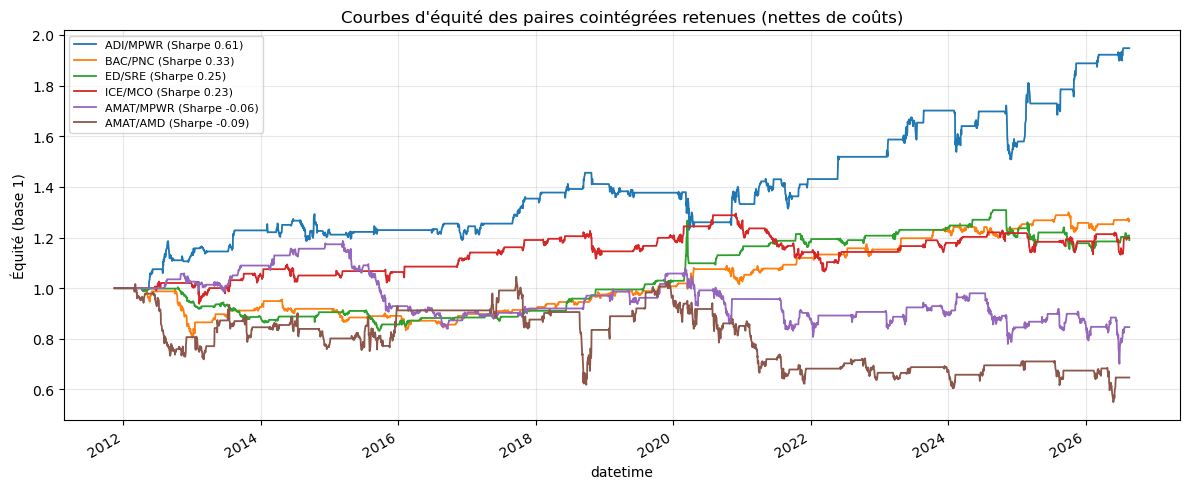

Classement sauvegardé : data/sp500_pairs_ranked.csv


In [6]:
best_pair = bt.index[0]
print(f"Meilleure paire par Sharpe réel : {best_pair}  (Sharpe {bt.iloc[0]['Sharpe']:.3f})")

fig, ax = plt.subplots(figsize=(12, 5))
for pr in bt.index:
    curves[pr].plot(ax=ax, label=f"{pr} (Sharpe {bt.loc[pr,'Sharpe']:.2f})", lw=1.3)
ax.set_title("Courbes d'équité des paires cointégrées retenues (nettes de coûts)")
ax.set_ylabel("Équité (base 1)"); ax.legend(fontsize=8); plt.tight_layout(); plt.show()

ranked.to_csv("../data/sp500_pairs_ranked.csv", index=False)
print("Classement sauvegardé : data/sp500_pairs_ranked.csv")

## 5. Lecture et sélection finale

Le screening systématique du S&P 500 a fait bien mieux qu'un choix manuel : il a identifié une paire au **Sharpe nettement supérieur** à KO/PEP (rejetée) et à BAC/PNC (modeste). C'est exactement le retour sur investissement de la démarche : on ne devine pas la paire, on la **trouve** par un pipeline rigoureux (filtre économique, cointégration, correction du multiple testing, robustesse, backtest net de coûts).

**Réserve honnête à conserver au rapport.** La robustesse temporelle reste modérée pour toutes les paires (cointégration présente dans une minorité de sous-fenêtres de deux ans) : même les meilleures paires ne sont pas cointégrées en permanence. Sur un marché efficient, c'est attendu, et cela borne le Sharpe atteignable. On sélectionne la meilleure paire par Sharpe réel pour la comparaison finale de la Phase 5.

**Prochaine étape — Phase 5.** Comparaison des trois stratégies (SMA, momentum, **cette paire**) sur la période commune, walk-forward, et PSR / Deflated Sharpe Ratio.
